# LAB 1 CODE

# PREPARATIONS

## Import libraries

In [112]:
import cv2
from PIL import Image, ImageOps, ImageCms, ImageDraw
import matplotlib.pyplot as plt
import numpy as np

from cv2.typing import MatLike

import os


## Custom helper functions

In [108]:
def plt_imshow(img: MatLike | Image.Image, title: String | None = None, cmap: String | int | None = None):
    if isinstance(img, Image.Image):
        plt.imshow(img, cmap=cmap)
    elif isinstance(img, np.ndarray):
        if cmap != None:
            plt.imshow(cv2.cvtColor(img, cmap))
        else:
            plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    
    plt.title(title)
    plt.axis("off")

# CODE

## 1. Cài đặt các thư viện OpenCV và Pillow

Image preparation

In [109]:
image_path = "../datatest/test.jpg"

## 2. Đọc và hiển thị ảnh:

CV2

True

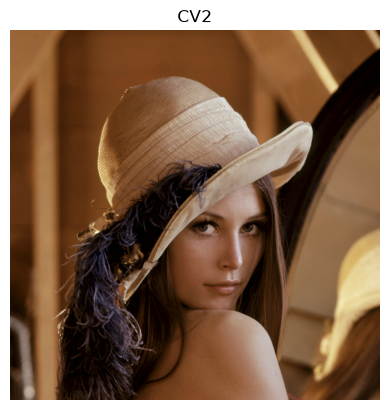

In [110]:
cv2_img = cv2.imread(image_path)

plt_imshow(cv2_img, "CV2")

cv2.imwrite("outputs/cv2_image.png", cv2_img)

Pillow

KeyboardInterrupt: 

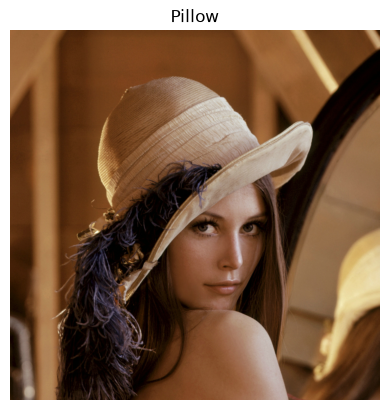

In [111]:
pil_img = Image.open(image_path)

plt_imshow(pil_img, "Pillow")

pil_img.save(f"{os.getcwd()}/outputs/pil_img.png")

## 3. Chuyển đổi không gian màu:

### Chuyển đổi ảnh từ RGB sang grayscale.

#### CV2

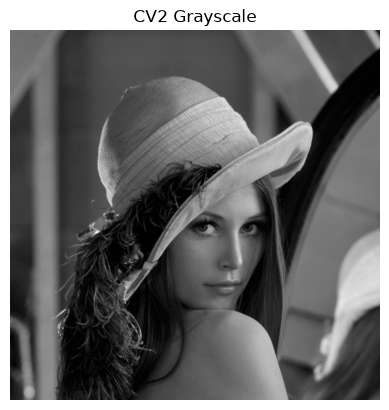

In [ ]:
cv2_gray = cv2.cvtColor(cv2_img, cv2.COLOR_BGR2GRAY)

plt_imshow(cv2_gray, "CV2 Grayscale")

#### Pillow

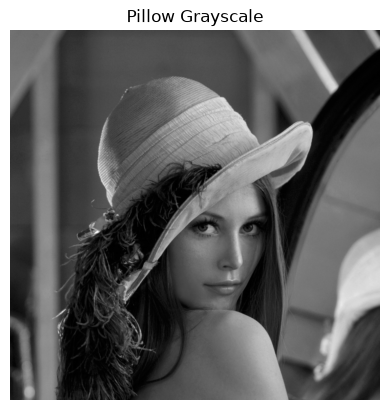

In [ ]:
pil_gray = ImageOps.grayscale(pil_img)

plt_imshow(pil_gray, "Pillow Grayscale", "gray")

### Chuyển đổi ảnh sang các không gian màu khác như HSV, LAB.

#### CV2

##### HSV

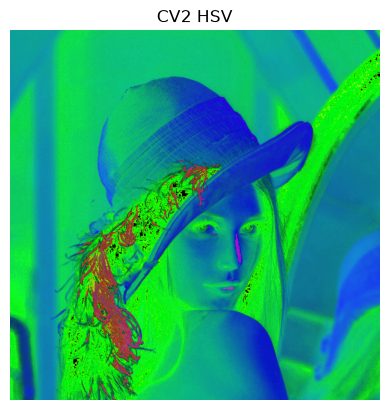

In [ ]:
plt_imshow(cv2_img, "CV2 HSV", cv2.COLOR_BGR2HSV)

##### LAB

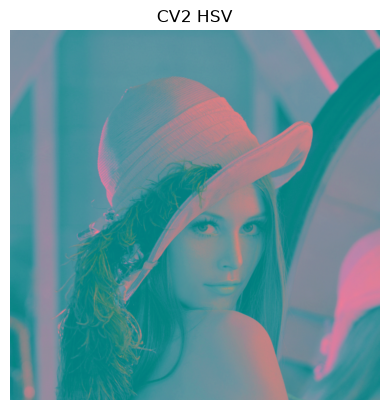

In [ ]:
plt_imshow(cv2_img, "CV2 HSV", cv2.COLOR_BGR2LAB)

#### Pillow

##### HSV

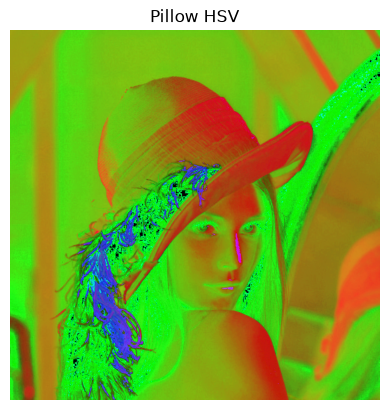

In [ ]:
pil_hsv = np.array(pil_img.convert("HSV"))
plt_imshow(pil_hsv, "Pillow HSV")

##### LAB

Source: https://www.reddit.com/r/Python/comments/94vmu1/rgb_to_lab/

In [ ]:
rgb_profile = ImageCms.createProfile(colorSpace='sRGB')
lab_profile = ImageCms.createProfile(colorSpace='LAB')

In [ ]:
# Create a transform object from the input and output profiles
rgb_to_lab_transform = ImageCms.buildTransform(
    inputProfile=rgb_profile,
    outputProfile=lab_profile,
    inMode='RGB',
    outMode='LAB'
)

In [ ]:
# Create a new image by applying the transform object to the source image
lab_image = ImageCms.applyTransform(
    im=pil_img,
    transform=rgb_to_lab_transform
)

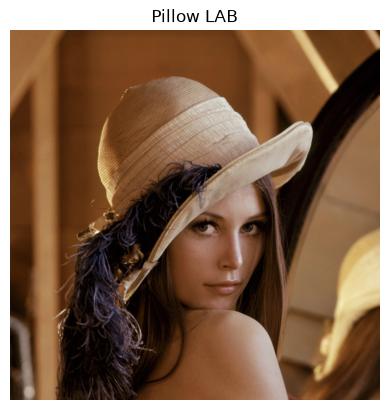

In [ ]:
plt_imshow(lab_image, "Pillow LAB")

## 4. Cắt xén và thay đổi kích thước:

### Cắt một vùng hình ảnh bất kỳ.

##### CV2

In [ ]:
h, w, _ = cv2_img.shape

In [ ]:
crop_y_end = min(300, h)
crop_x_end = min(400, w)

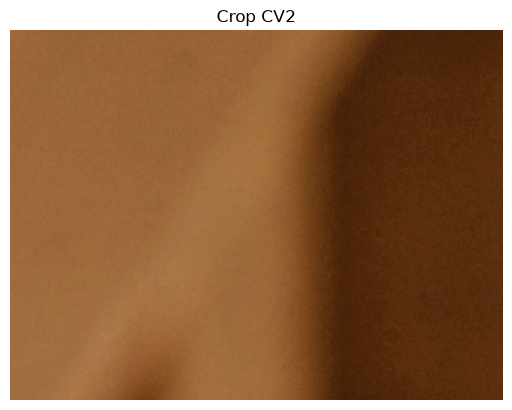

In [ ]:
crop_cv2 = cv2_img[0:crop_y_end, 0:crop_x_end]
plt_imshow(crop_cv2, "Crop CV2")

##### Pillow

In [ ]:
w, h = pil_img.size

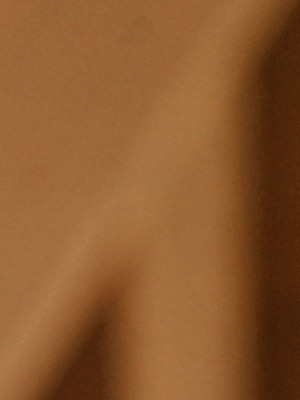

In [ ]:
crop_start = (0, 0)
crop_end = (min(w, 300), min(h, 400))
pil_img.crop((crop_start[0], crop_start[1], crop_end[0], crop_end[1]))

### Thay đổi kích thước hình ảnh theo tỷ lệ hoặc kích thước cố định.

##### CV2

Ratio resize

In [ ]:
ratio_y = 0.5
ratio_x = 0.5

In [ ]:
w, h, _ = cv2_img.shape
print("Original size: ", w, h)

Original size:  1960 1960


Resized size:  980 980


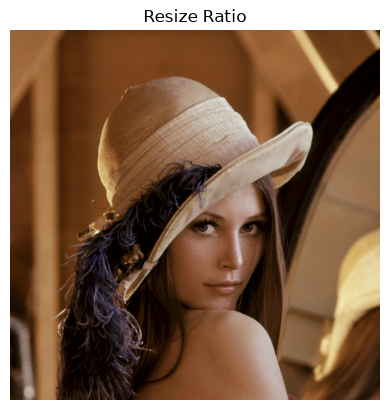

In [ ]:
cv2_resize_ratio = cv2.resize(cv2_img, dsize=(0,0), fx=ratio_x, fy=ratio_y)

plt_imshow(cv2_resize_ratio, "Resize Ratio")

w, h, _ = cv2_resize_ratio.shape
print("Resized size: ", w, h)


Fixed resize

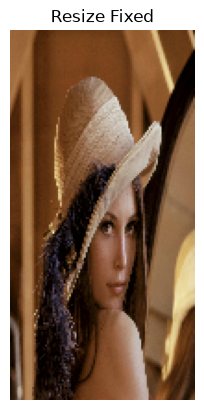

In [ ]:
cv2_resize_fixed = cv2.resize(cv2_img, dsize=(100,200))

plt_imshow(cv2_resize_fixed, "Resize Fixed")

##### Pillow

Ratio

In [ ]:
w, h = pil_img.size
print("Original size: ", w, h)

Original size:  1960 1960


In [ ]:
ratio_x = 0.5
ratio_y = 0.5

Resized size:  980 980


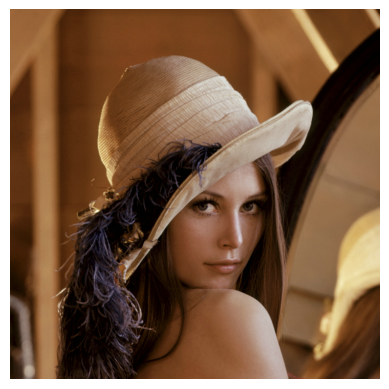

In [ ]:
pil_resize_ratio = pil_img.resize((int(ratio_x*w), int(ratio_y*h)))

plt_imshow(pil_resize_ratio)

res_w, res_h = pil_resize_ratio.size
print("Resized size: ", res_w, res_h)

Fixed

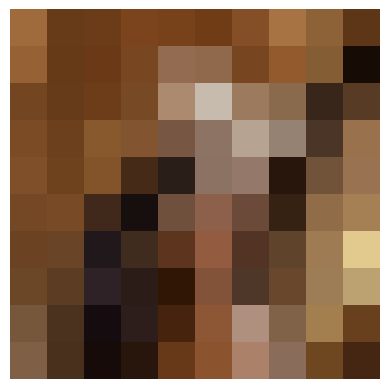

In [ ]:
pil_resize_ratio = pil_img.resize(size=(10, 10))

plt_imshow(pil_resize_ratio)

## 5. Vẽ hình cơ bản

### Vẽ các hình cơ bản như đường thẳng, hình tròn, hình chữ nhật lên hình ảnh.

#### CV2

In [ ]:
cv2_drawing_img = cv2_img.copy()

##### Line

In [ ]:
line_pos_start = (0,0)
line_pos_end = (300, 400)
line_col = (255, 0, 0)
line_thickness = 67

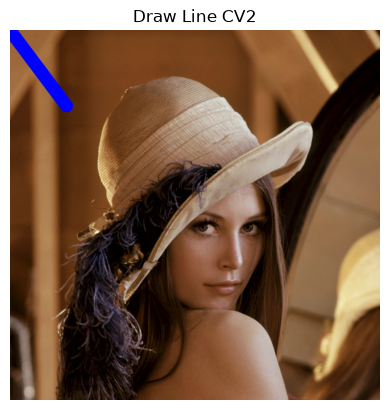

In [ ]:
cv2.line(cv2_drawing_img, line_pos_start, line_pos_end, line_col, line_thickness)

plt_imshow(cv2_drawing_img, "Draw Line CV2")

##### Rectangle

In [ ]:
rec_pos_start = (0,0)
rec_pos_end = (500, 200)
rec_col = (0,0,255)
rec_thickness = -1

##### Circle

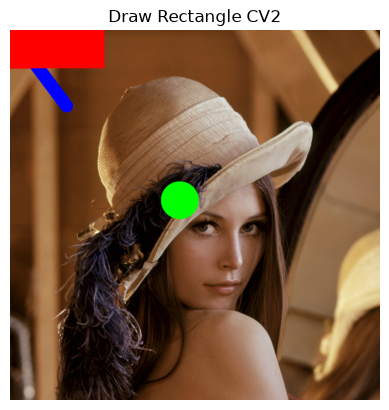

In [ ]:
cv2.rectangle(cv2_drawing_img, rec_pos_start, rec_pos_end, rec_col, rec_thickness)

plt_imshow(cv2_drawing_img, "Draw Rectangle CV2")

In [ ]:
circle_pos = (900, 900)
circle_rad = 100
circle_col = (0,255,0)
circle_thickness = -1

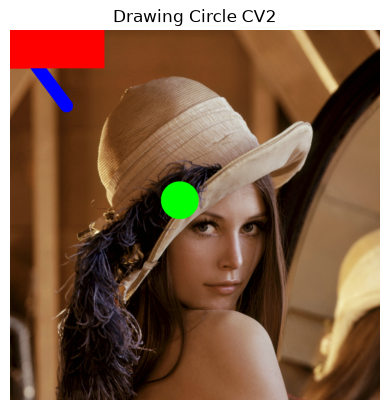

In [ ]:
cv2.circle(cv2_drawing_img, circle_pos, circle_rad, circle_col, circle_thickness)

plt_imshow(cv2_drawing_img, "Drawing Circle CV2")

##### Text

In [ ]:
txt = "aaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaa"
txt_pos = (500,500)
font = cv2.FONT_HERSHEY_COMPLEX
txt_scale = 10
txt_col = (255, 0, 255)
txt_thickness = 2

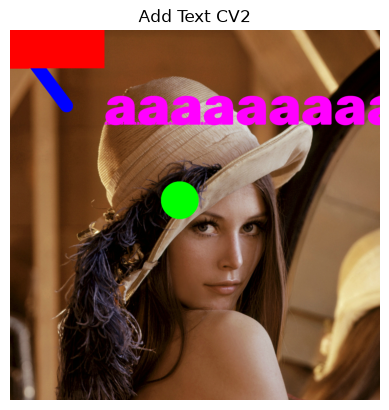

In [ ]:
cv2.putText(cv2_drawing_img, txt, txt_pos, font, txt_scale, txt_col, txt_thickness)

plt_imshow(cv2_drawing_img, "Add Text CV2")

#### Pillow

In [134]:
pil_drawing_img = Image.open(image_path)
pil_drawing = ImageDraw.Draw(pil_drawing_img)

##### Line

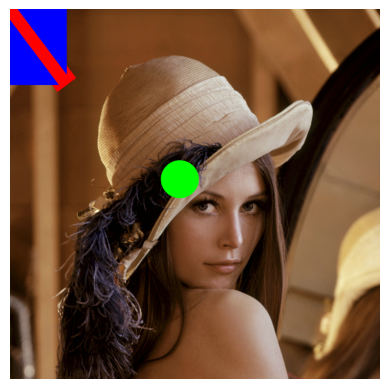

In [151]:
pil_drawing.line([line_pos_start, line_pos_end], fill=line_col, width=line_thickness)
plt_imshow(pil_drawing_img)

##### Rectangle

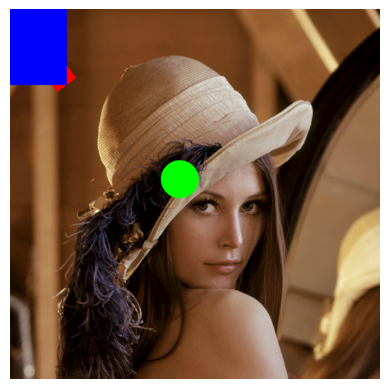

In [150]:
pil_drawing.rectangle([line_pos_start, line_pos_end], fill=rec_col, width=rec_thickness)
plt_imshow(pil_drawing_img)

##### Circle

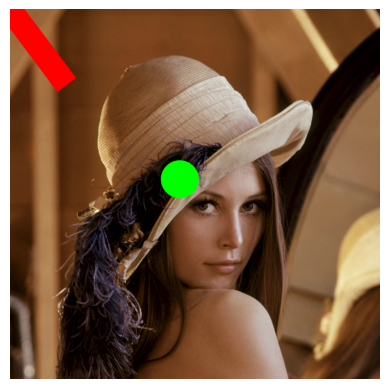

In [149]:
pil_drawing.circle(circle_pos, circle_rad, fill=circle_col, width=circle_thickness)
plt_imshow(pil_drawing_img)

##### Text

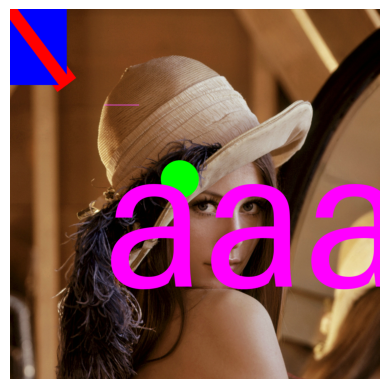

In [158]:
pil_drawing.text(txt_pos, txt, fill=txt_col, font=None, font_size=txt_thickness)
plt_imshow(pil_drawing_img)